In [1]:
import time, copy
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

from adoptionopinions_model import initial_state_factory, simulation_constants_factory, Simulation, Networks
from networks import network_factory, regular_lattice, random_complete, influencer_network, ring

%load_ext autoreload
%autoreload 2
print("done")

done


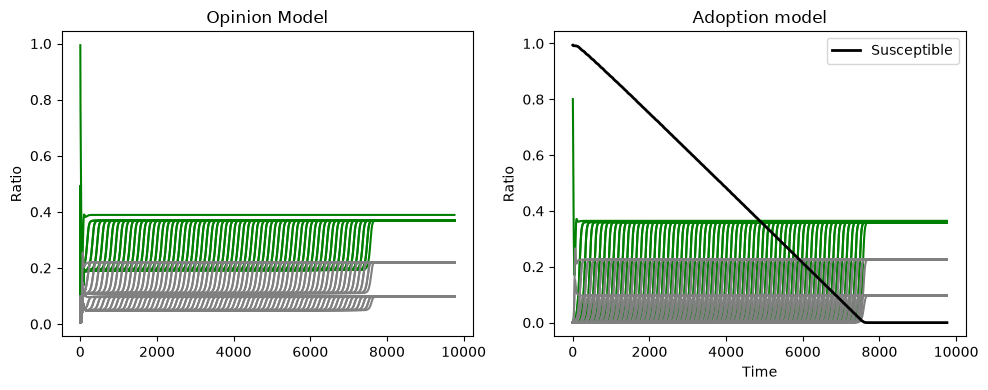

2 -> 7779


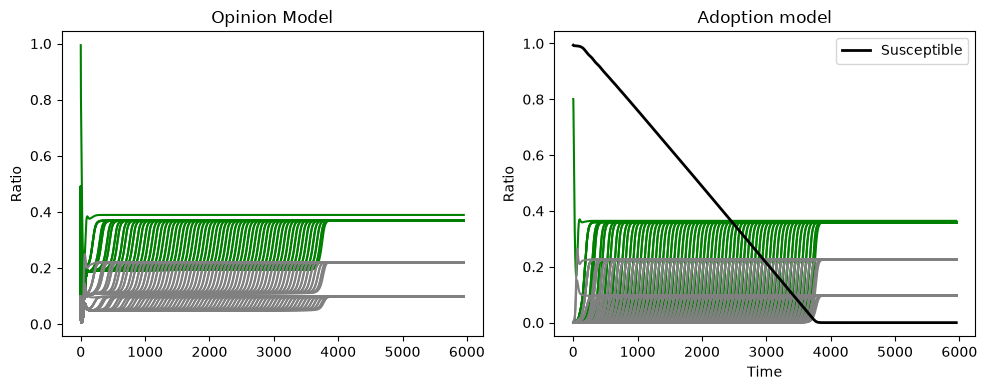

4 -> 3963


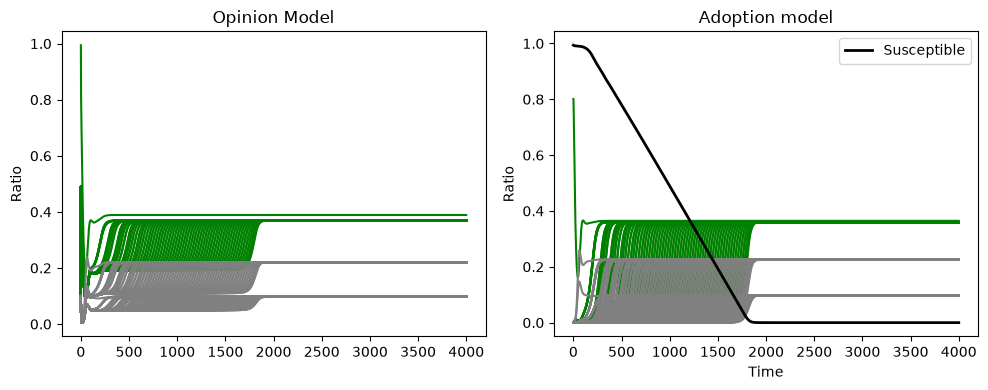

8 -> 2017


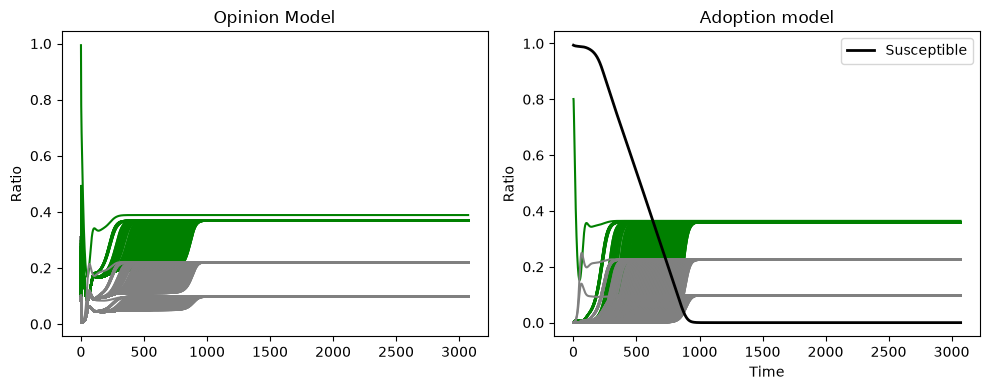

16 -> 1099


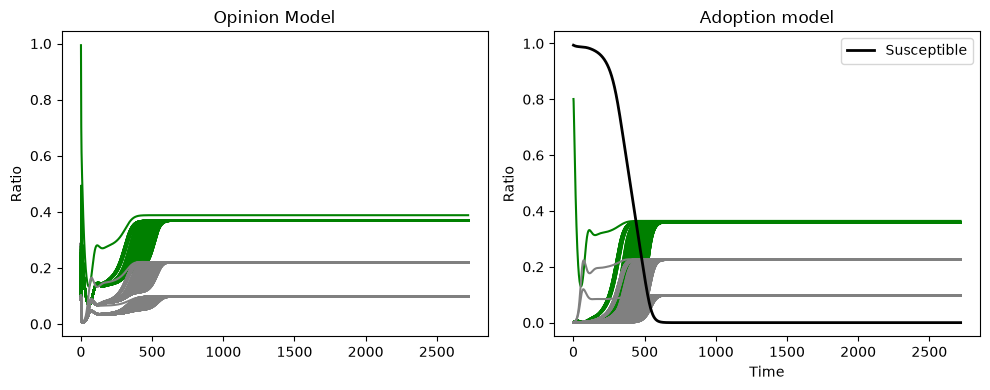

32 -> 757


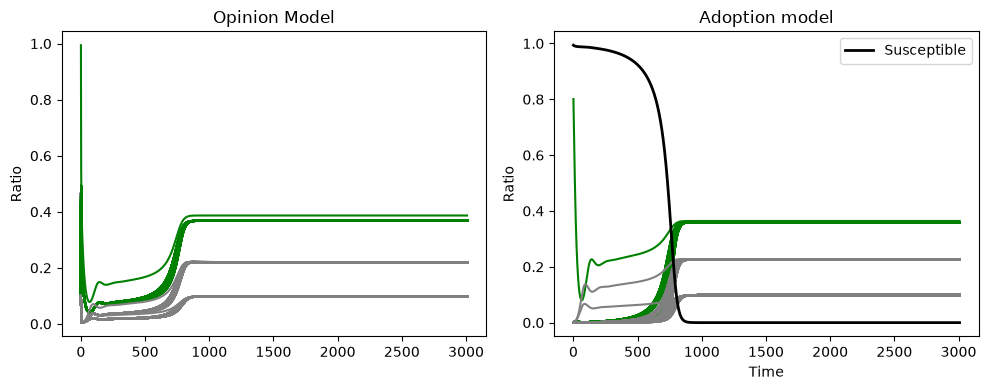

64 -> 1106


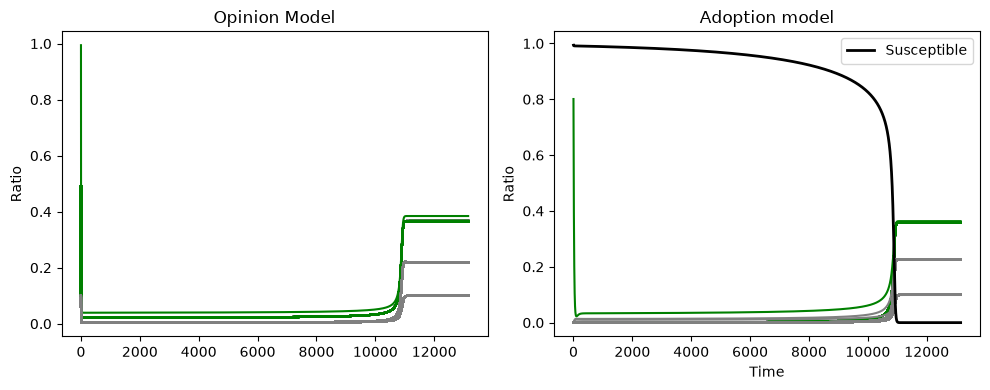

128 -> 11249


In [17]:
# Physical network experiment

def run(n, k, n_influencers):
 
    start = np.random.randint(0,n)
    influencers = None
    V = random_complete(n)
    if n_influencers > 0:
        influencers = influencers = np.round(np.linspace(start, n+start, n_influencers, endpoint=False))
        influencers = [int(i) % n for i in influencers]
        V = influencer_network(n, influencers)
        
    initial_states = initial_state_factory(n, k, adopters=influencers)
    constants      = simulation_constants_factory(n,k, copy.deepcopy(initial_states.x))
    W = ring(n)
    net = Networks(W, V)

    p = int(np.log2(n))
    for degree in [2 ** i for i in range(1, p+1)]:
        net.W = regular_lattice(n,degree, self_loop=True)
        sim = Simulation(constants, initial_states, net)
        while (not sim(True)):
            pass

        res = sim.results()
            
        print(f"{degree} -> {res.a_converged_at}")
        #adoptions.append([state.a for state in sim.states])
run(128, 3, 1)

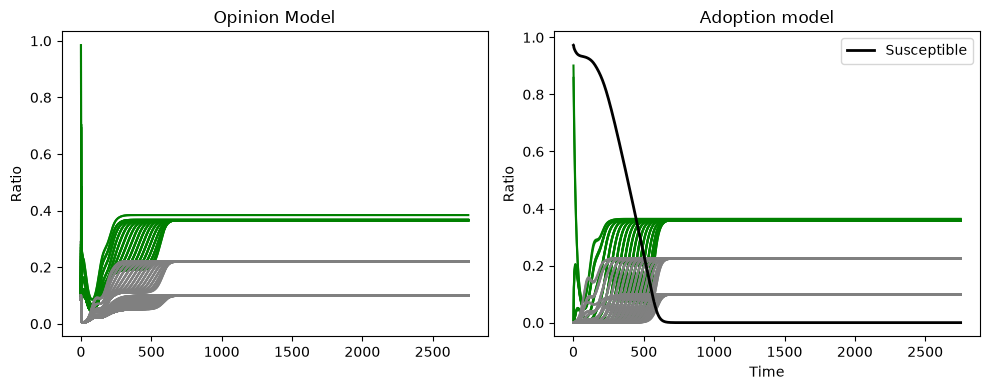

2 -> 798


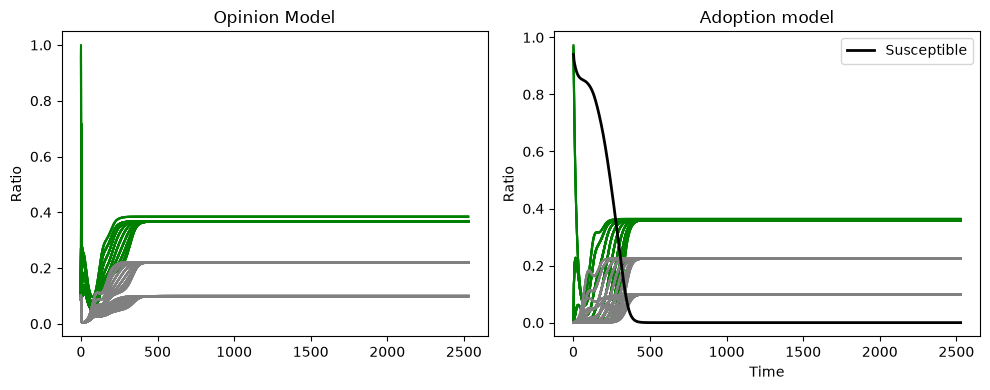

4 -> 564


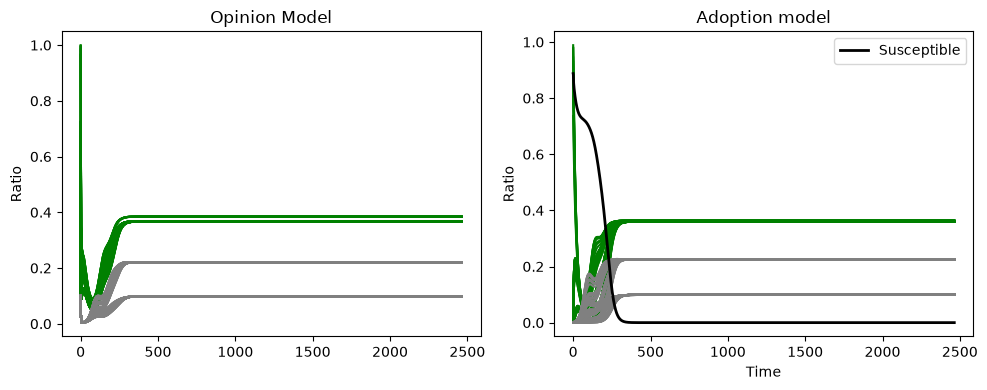

8 -> 541


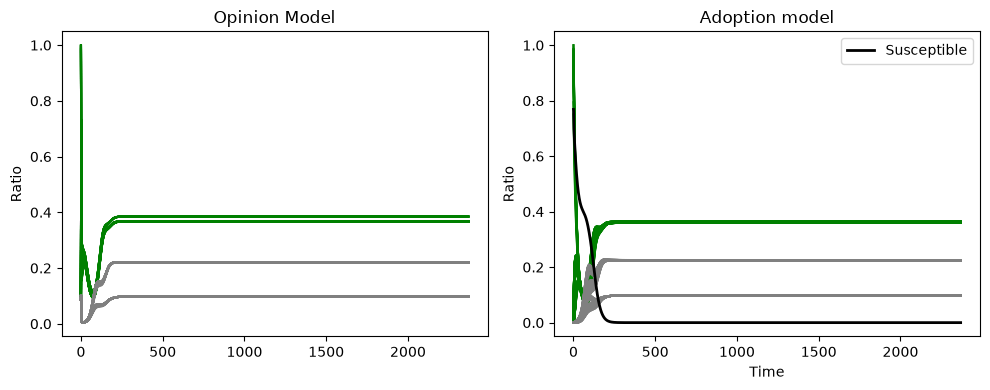

16 -> 457


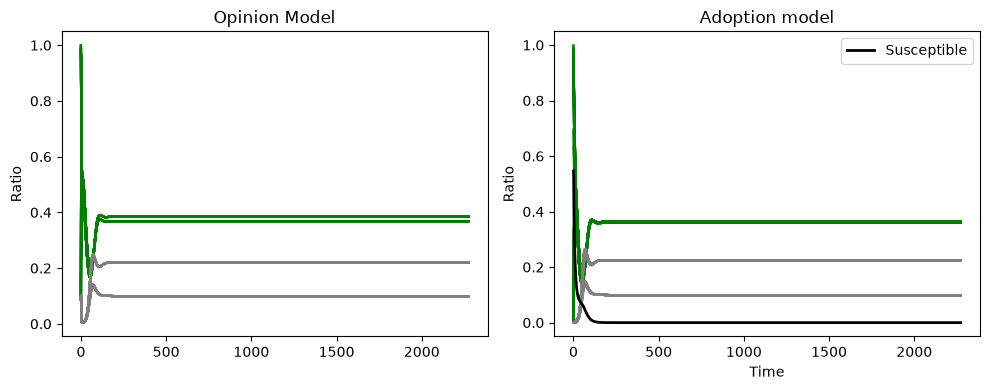

32 -> 374


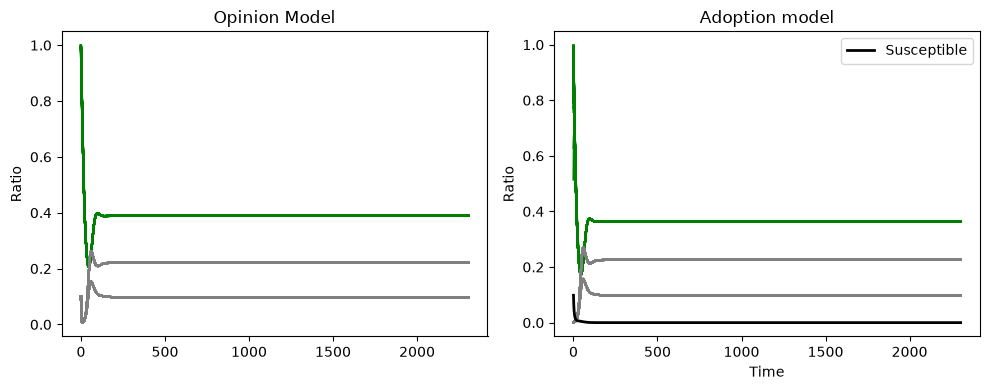

64 -> 391


In [14]:
# Non-physical experiment
def run(n, k):

    start = np.random.randint(0,n)
    p = int(np.log2(n))
    for n_influencers in [2 ** i for i in range(1, p+1)]:
        
        influencers = influencers = np.round(np.linspace(start, n+start, n_influencers, endpoint=False))
        influencers = [int(i) % n for i in influencers]
        initial_states = initial_state_factory(n, k, adopters=influencers)
        constants      = simulation_constants_factory(n,k, copy.deepcopy(initial_states.x))
        V = influencer_network(n, influencers)
        net = Networks(W=ring(n), V=V)
        sim = Simulation(constants, initial_states, net)
        
        while (not sim(True)):
            pass

        res = sim.results()
            
        print(f"{n_influencers} -> {res.a_converged_at}")
        #adoptions.append([state.a for state in sim.states])
run(64, 3)